In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import astropy as ap
import scipy as si
import numpy as np

In [ ]:
#part here to initialize the data frame
"""
parameters
-mass of the star
-time since simulation started
-fraction of hydrogen (X)
-fraction of helium (Y)
-other elements (Z)
-core temp


assumptions
-will only fuse hydrogen and helium, other elements in high-mass stars are negligible in terms of extending stellar lifespan
-focusing on P-P chain and CNO cycle processes
"""
time = 0
X = 0.75
Y = 0.25
Z = 0.0
bin_width = 10e4 #discrete period over which the simulation runs, in seconds
total_initial_mass = 1 #a value between 0.08 and 100 solar massess

main_df = [time, X, Y, Z, core_mass(total_initial_mass)]

In [ ]:
#defining functions to update the data frame
#lane-emden equations with exponent n = 3
#use polytropic approach for simplifications; need definite integrals

"""
Model approach: Hydrostatic equilibrium + energy
To maintain hydrostatic equilibrium, the star must have a certain amount of pressure counteracting gravity at a given radius
We can calculate how much energy is released from each of the main reaction types, and and convert it to a pressure?
This perhaps can be done via the ideal gas law.
"""
ε_pp ≈ 2.4 × 10⁴ ρ X² (T/10⁷K)⁴ erg/g/s
ε_CNO ≈ 8.7 × 10²⁷ ρ X X_CNO (T/10⁷K)^19.9 erg/g/s

def update_table(current_core_mass, time, X, Y, Z, temperature): #append to existing data table
    if M < 1.3 #PP chain

    else #CNO cycle

#function of mass of star that ends up in fusion; ideally smooth
def core_mass(total_initial_mass):
    return f(total_initial_mass) #replace with function

In [1]:
#code to produce the real-time visuals
"""
this part will work by plotting the stellar core on a 2D cartesian grid as rings of elements
as a simplification (just for visuals), the radius of each ring is just linearly proportional to the fraction of elements, instead of calculating volume
i.e.
r1 = X+Y+Z, r2 = Y+Z, r3 = Z
how to make a real-time sim? how to make a slider to go back and forth on the timeline?
how to plot circle & change color? likely matplotlib library
"""

'\nthis part will work by plotting the stellar core on a 2D cartesian grid as rings of elements\nas a simplification (just for visuals), the radius of each ring is just linearly proportional to the fraction of elements, instead of calculating volume\ni.e.\nr1 = X+Y+Z, r2 = Y+Z, r3 = Z\nhow to make a real-time sim? how to make a slider to go back and forth on the timeline?\nhow to plot circle & change color? likely matplotlib library\n'

RED DWARF STELLAR EVOLUTION MODEL (FIXED)
Surface found at ξ = 3.6538

Stellar structure for 0.30 M☉, X=0.750:
  Radius: 0.382 R☉ (2.656e+10 cm)
  Central density: 4.552e+01 g/cm³
  Central temperature: 5.777e+06 K (5.78 MK)
  Mean molecular weight: 0.589

Stellar structure for 0.30 M☉, X=0.740:
  Radius: 0.382 R☉ (2.656e+10 cm)
  Central density: 4.552e+01 g/cm³
  Central temperature: 5.820e+06 K (5.82 MK)
  Mean molecular weight: 0.593

Stellar structure for 0.30 M☉, X=0.730:
  Radius: 0.382 R☉ (2.656e+10 cm)
  Central density: 4.552e+01 g/cm³
  Central temperature: 5.864e+06 K (5.86 MK)
  Mean molecular weight: 0.598

Stellar structure for 0.30 M☉, X=0.720:
  Radius: 0.382 R☉ (2.656e+10 cm)
  Central density: 4.552e+01 g/cm³
  Central temperature: 5.908e+06 K (5.91 MK)
  Mean molecular weight: 0.602

Stellar structure for 0.30 M☉, X=0.710:
  Radius: 0.382 R☉ (2.656e+10 cm)
  Central density: 4.552e+01 g/cm³
  Central temperature: 5.953e+06 K (5.95 MK)
  Mean molecular weight: 0.607


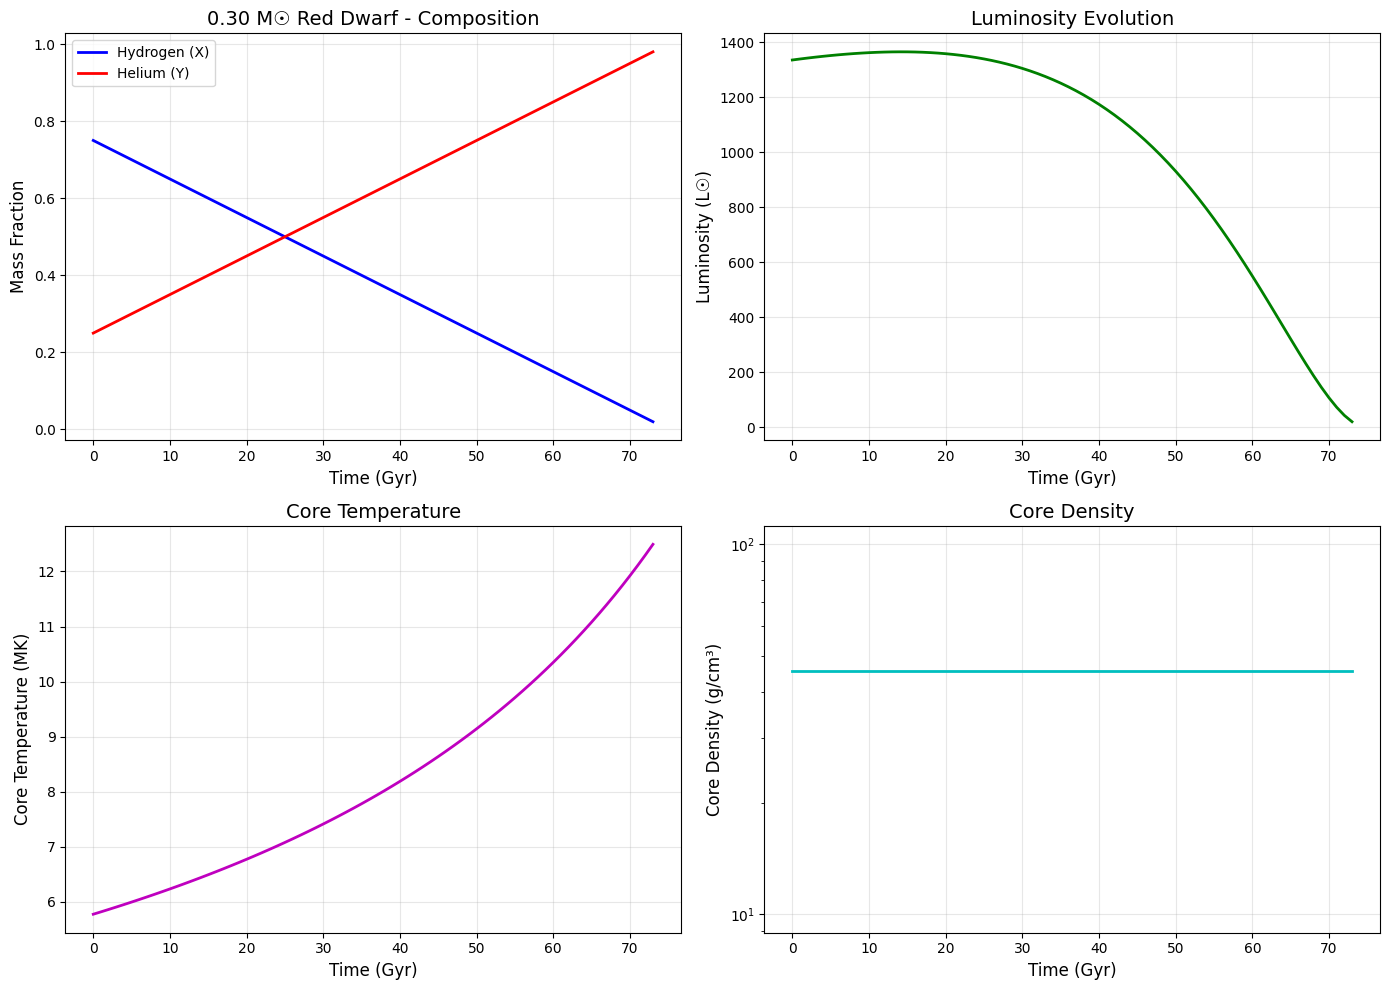


SUMMARY
Mass: 0.3 M☉
Lifetime: 73.0 Gyr
Initial luminosity: 1335.320396 L☉
Final luminosity: 20.762682 L☉
Initial T_core: 5.78 MK


In [3]:
import numpy as np
from scipy.integrate import solve_ivp, simpson
import matplotlib.pyplot as plt

# Physical constants
M_sun = 1.989e33  # g
R_sun = 6.96e10   # cm
L_sun = 3.828e33  # erg/s
G = 6.674e-8      # cm³/g/s²
k_B = 1.381e-16   # erg/K
m_p = 1.673e-24   # g

class RedDwarfModel:
    def __init__(self, M_solar_masses):
        self.M = M_solar_masses * M_sun
        self.M_solar = M_solar_masses
        self.n = 1.5  # Polytropic index
        
        # Solve Lane-Emden
        self.solve_lane_emden()
        
    def lane_emden_eq(self, xi, y):
        """Lane-Emden equation - fixed for numerical stability"""
        theta, dtheta = y
        
        # Prevent negative theta
        if theta < 0:
            theta = 0
        
        if xi < 1e-6:  # Near center
            d2theta = -1.0/3.0  # theta^n ≈ 1 at center
        else:
            d2theta = -theta**self.n - (2.0/xi) * dtheta
        
        return [dtheta, d2theta]
    
    def solve_lane_emden(self):
        """Solve Lane-Emden equation using solve_ivp"""
        # Initial conditions
        y0 = [1.0, 0.0]  # theta(0)=1, dtheta/dxi(0)=0
        
        # Event to stop at surface (theta=0)
        def surface_event(xi, y):
            return y[0]  # Stop when theta = 0
        surface_event.terminal = True
        surface_event.direction = -1
        
        # Integrate
        sol = solve_ivp(
            self.lane_emden_eq,
            [1e-6, 20],  # xi range
            y0,
            events=surface_event,
            dense_output=True,
            max_step=0.01,
            method='RK45'
        )
        
        # Extract solution
        self.xi = sol.t
        self.theta = sol.y[0]
        self.dtheta = sol.y[1]
        self.xi_surface = self.xi[-1]
        
        print(f"Surface found at ξ = {self.xi_surface:.4f}")
        
    def get_structure(self, X=0.75):
        """Calculate stellar structure"""
        # Mean molecular weight (fully ionized H+He)
        Y = 1.0 - X
        mu = 1.0 / (2.0*X + 0.75*Y + 0.5*0.02)  # Small metal contribution
        
        # Mass-radius relation for red dwarfs
        # Empirical: R/R_sun ≈ M/M_sun for M < 0.6
        self.R = (self.M_solar**0.8) * R_sun
        
        # Scaling factor
        self.alpha = self.R / self.xi_surface
        
        # Central density from normalization
        # M = 4π α³ ρ_c ∫ξ² θ^n dξ
        integrand = self.xi**2 * np.abs(self.theta)**self.n
        integral = simpson(integrand, self.xi)
        
        self.rho_c = self.M / (4.0 * np.pi * self.alpha**3 * integral)
        
        # Central temperature
        # Use virial theorem: GM*mu*mp/(k*R)
        # But divide by ~2 for core vs average
        T_virial = G * self.M * mu * m_p / (k_B * self.R)
        self.T_c = T_virial * 0.54  # Empirical factor for n=1.5 polytrope
        
        print(f"\nStellar structure for {self.M_solar:.2f} M☉, X={X:.3f}:")
        print(f"  Radius: {self.R/R_sun:.3f} R☉ ({self.R:.3e} cm)")
        print(f"  Central density: {self.rho_c:.3e} g/cm³")
        print(f"  Central temperature: {self.T_c:.3e} K ({self.T_c/1e6:.2f} MK)")
        print(f"  Mean molecular weight: {mu:.3f}")
        
        # Sanity checks
        if np.isnan(self.rho_c) or np.isnan(self.T_c):
            raise ValueError("Got NaN in structure calculation!")
        if self.rho_c <= 0 or self.T_c <= 0:
            raise ValueError("Got non-positive values!")
        
        return self.rho_c, self.T_c, self.R
    
    def epsilon_pp(self, rho, T, X):
        """PP-chain energy generation rate (erg/g/s)"""
        if X < 1e-6:
            return 0.0
        
        eps = 2.4e4 * rho * X**2 * (T/1e7)**4
        
        # Check for numerical issues
        if np.isnan(eps) or eps < 0:
            return 0.0
        
        return eps
    
    def calculate_luminosity(self, X):
        """Integrate energy generation over star"""
        # Physical radius array
        r = self.alpha * self.xi
        
        # Density profile
        rho = self.rho_c * np.abs(self.theta)**self.n
        
        # Temperature profile: T ∝ theta^(n*(gamma-1))
        # For n=1.5, gamma=5/3, so n*(gamma-1) = 1.5*2/3 = 1
        T = self.T_c * np.abs(self.theta)
        
        # Energy generation at each point
        eps = np.zeros_like(r)
        for i in range(len(r)):
            eps[i] = self.epsilon_pp(rho[i], T[i], X)
        
        # Integrate L = ∫ 4πr² ρ ε dr
        integrand = 4.0 * np.pi * r**2 * rho * eps
        L = simpson(integrand, r)
        
        return L / L_sun  # Solar luminosities
    
    def evolve(self, t_max_years=5e11, dt_years=5e8, X_initial=0.75):
        """Evolve the red dwarf"""
        X = X_initial
        Y = 1.0 - X
        time = 0.0
        
        data = {
            'time': [],
            'X': [],
            'Y': [],
            'T_core': [],
            'rho_core': [],
            'L': [],
            'R': []
        }
        
        # Get initial structure
        try:
            self.get_structure(X)
        except Exception as e:
            print(f"Error in initial structure: {e}")
            return data
        
        yr_to_sec = 3.156e7
        
        step = 0
        while X > 0.01 and time < t_max_years:
            # Calculate luminosity
            try:
                L = self.calculate_luminosity(X)
            except Exception as e:
                print(f"Error calculating luminosity at step {step}: {e}")
                break
            
            # Check for bad values
            if np.isnan(L) or L <= 0:
                print(f"Invalid luminosity: {L}")
                break
            
            # Store data
            data['time'].append(time / 1e9)  # Gyr
            data['X'].append(X)
            data['Y'].append(Y)
            data['T_core'].append(self.T_c / 1e6)  # MK
            data['rho_core'].append(self.rho_c)
            data['L'].append(L)
            data['R'].append(self.R / R_sun)
            
            # Hydrogen consumption
            Q_pp = 26.7 * 1.602e-6  # erg per reaction (4H → He)
            dt_sec = dt_years * yr_to_sec
            
            # Energy radiated this timestep
            energy = L * L_sun * dt_sec  # erg
            
            # Mass of hydrogen consumed
            # Each reaction: 4 protons → 1 He + energy
            n_reactions = energy / Q_pp
            M_H_consumed = n_reactions * 4.0 * m_p
            
            # Change in mass fraction
            dX = -M_H_consumed / self.M
            
            # Safety check on timestep
            if abs(dX) > 0.01:  # Don't change X by more than 1% per step
                dX = -0.01 if dX < 0 else 0.01
                print(f"Warning: Limiting dX to {dX:.4f}")
            
            X += dX
            Y = 1.0 - X
            
            # Don't let X go negative
            if X < 0:
                X = 0
                break
            
            # Recalculate structure
            try:
                self.get_structure(X)
            except Exception as e:
                print(f"Error updating structure: {e}")
                break
            
            time += dt_years
            step += 1
            
            if step % 50 == 0:
                print(f"\nStep {step}: t={time/1e9:.2f} Gyr, X={X:.4f}, L={L:.6f} L☉")
        
        print(f"\n{'='*60}")
        print("Evolution complete!")
        print(f"Final time: {time/1e9:.1f} Gyr")
        print(f"Final X: {X:.4f}")
        print(f"Steps: {step}")
        
        return data

def plot_evolution(data, M_solar):
    """Plot results"""
    if len(data['time']) == 0:
        print("No data to plot!")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Composition
    axes[0, 0].plot(data['time'], data['X'], 'b-', linewidth=2, label='Hydrogen (X)')
    axes[0, 0].plot(data['time'], data['Y'], 'r-', linewidth=2, label='Helium (Y)')
    axes[0, 0].set_xlabel('Time (Gyr)', fontsize=12)
    axes[0, 0].set_ylabel('Mass Fraction', fontsize=12)
    axes[0, 0].set_title(f'{M_solar:.2f} M☉ Red Dwarf - Composition', fontsize=14)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Luminosity
    axes[0, 1].plot(data['time'], data['L'], 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Time (Gyr)', fontsize=12)
    axes[0, 1].set_ylabel('Luminosity (L☉)', fontsize=12)
    axes[0, 1].set_title('Luminosity Evolution', fontsize=14)
    axes[0, 1].grid(alpha=0.3)
    
    # Core temperature
    axes[1, 0].plot(data['time'], data['T_core'], 'm-', linewidth=2)
    axes[1, 0].set_xlabel('Time (Gyr)', fontsize=12)
    axes[1, 0].set_ylabel('Core Temperature (MK)', fontsize=12)
    axes[1, 0].set_title('Core Temperature', fontsize=14)
    axes[1, 0].grid(alpha=0.3)
    
    # Core density
    axes[1, 1].semilogy(data['time'], data['rho_core'], 'c-', linewidth=2)
    axes[1, 1].set_xlabel('Time (Gyr)', fontsize=12)
    axes[1, 1].set_ylabel('Core Density (g/cm³)', fontsize=12)
    axes[1, 1].set_title('Core Density', fontsize=14)
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'red_dwarf_{M_solar:.2f}Msun_fixed.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run the model
if __name__ == "__main__":
    print("="*60)
    print("RED DWARF STELLAR EVOLUTION MODEL (FIXED)")
    print("="*60)
    
    M = 0.3  # Solar masses
    
    try:
        star = RedDwarfModel(M)
        data = star.evolve(t_max_years=5e11, dt_years=1e9)  # 1 Gyr timesteps
        plot_evolution(data, M)
        
        # Summary
        if len(data['time']) > 0:
            print("\n" + "="*60)
            print("SUMMARY")
            print("="*60)
            print(f"Mass: {M} M☉")
            print(f"Lifetime: {data['time'][-1]:.1f} Gyr")
            print(f"Initial luminosity: {data['L'][0]:.6f} L☉")
            print(f"Final luminosity: {data['L'][-1]:.6f} L☉")
            print(f"Initial T_core: {data['T_core'][0]:.2f} MK")
    
    except Exception as e:
        print(f"Error running model: {e}")
        import traceback
        traceback.print_exc()